# Question 1: Revenue and Growth by Category

## Objective
Identify which product categories are driving revenue growth and which are declining, to inform Q4 strategic priorities.

## Approach
- Joined orders, order_items, and products tables to create one analysis-ready dataset (112,650 rows)
- Translated Portuguese category names to English (and manually fixed 2 untranslated categories: pc_gamer and portateis_cozinha_e_preparadores_de_alimentos)
- Calculated revenue concentration (Pareto analysis)
- Compared 2017 vs 2018 growth using only Jan-Aug data from both years to ensure fair comparison

## Key Findings

### Finding 1: Revenue is moderately concentrated
- 16 out of 73 categories drive 80% of total revenue (22% of categories)
- The top 5 categories (health_beauty, watches_gifts, bed_bath_table, sports_leisure, computers_accessories) account for 40.3% of revenue
- The top 3 categories alone are within 22% of each other in revenue, suggesting no single category dominates
- This is more diversified than a typical marketplace, but still creates exposure if the top 16 categories underperform

### Finding 2: Strategic growers worth investing in
- health_beauty: 2018 revenue of 772,238 BRL with 211.5% YoY growth
- watches_gifts: 2018 revenue of 708,851 BRL with 237.2% YoY growth
- bed_bath_table: 2018 revenue of 538,069 BRL with 107.1% YoY growth
- sports_leisure: 2018 revenue of 532,566 BRL with 134.0% YoY growth
- computers_accessories: 2018 revenue of 505,476 BRL with 128.1% YoY growth

These categories are both large in absolute terms and growing fast. Together they added 1.8M BRL in incremental revenue between 2017 and 2018. They deserve marketing investment and inventory expansion.

### Finding 3: Declining categories that need intervention
- market_place: -50.5% YoY decline (15,280 BRL to 7,565 BRL)
- home_confort: -4.5% YoY decline (21,863 BRL to 20,883 BRL)

Only two categories actually shrank in absolute terms. The overall marketplace grew 137% year over year (3.11M to 7.39M BRL Jan-Aug), so the real story is growth disparity rather than widespread decline. market_place may not be a true product category and is worth investigating with the business.

### Finding 4: Emerging high-growth categories to monitor
Smaller categories growing exceptionally fast, potential future strategic priorities:
- home_appliances_2: 597.9% growth (12,788 BRL to 89,252 BRL)
- home_appliances: 295.7% growth
- stationery: 264.5% growth
- baby: 262.8% growth (notable as it reached meaningful scale at 256,800 BRL in 2018)
- electronics: 247.1% growth

The baby category stands out for combining high growth rate with substantial scale.

### Finding 5: November 2017 reveals seasonality
Monthly revenue shows November 2017 at 1,010,271 BRL, significantly higher than surrounding months (October 664K, December 743K). This aligns with Black Friday in Brazil (November 24, 2017). Seasonality should be considered in any forecasting work.

### Finding 6: Time data limitations
- 2016 has only 4 months of data (Sept-Dec) and very low volume (50K BRL total)
- 2018 has data through October only, with September dropping to just 145 BRL (clearly cut off mid-month)
- Direct year-over-year comparisons need to use matching months for fairness
- All growth analyses use Jan-Aug 2017 vs Jan-Aug 2018

## Limitations
- 610 products have no category assignment (1.9% of products) and were excluded from category analysis
- Growth analysis only covers 8 months of comparable data
- Cannot determine whether growth is from new customers or existing customers buying more (will tackle in customer analysis)
- The two manually translated categories (pc_gamer, portateis_cozinha_e_preparadores_de_alimentos) may need business validation

## Recommendations for Q4
1. Increase marketing spend on the top 5 strategic growers, particularly health_beauty and watches_gifts which combine highest growth with largest absolute revenue
2. Investigate the home_appliances_2 category specifically (597% growth) to confirm whether this represents a category change or genuine market expansion
3. Investigate market_place decline (50% drop) to confirm whether this is a true category or data classification artifact
4. Evaluate whether the long tail of 57 categories doing less than 20% of revenue justifies the operational complexity
5. Set up a recurring monthly review of category-level revenue trends with November flagged for seasonal context
6. Establish baby category as a strategic priority given its combination of high growth and meaningful scale

## Next Analysis
Customer behavior. Who's buying these growing categories? Repeat customers or first-timers? Given the 3.5% repeat rate observed in Day 2, understanding whether the 137% growth is driven by new customer acquisition or deeper engagement with existing customers is the critical next question.

In [ ]:
# E-commerce Sales Analysis — Day 3: Revenue and Growth by Category
# Author: Rohan Vishwakarma

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
pd.set_option('display.max_colwidth', 100)

# Load the tables we need today
DATA_DIR = Path('../data/raw')

orders = pd.read_csv(DATA_DIR / 'olist_orders_dataset.csv')
order_items = pd.read_csv(DATA_DIR / 'olist_order_items_dataset.csv')
products = pd.read_csv(DATA_DIR / 'olist_products_dataset.csv')
category_translation = pd.read_csv(DATA_DIR / 'product_category_name_translation.csv')

# Convert date column right away (we learned this yesterday)
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])

print("Data loaded ✅")
print(f"orders: {orders.shape}")
print(f"order_items: {order_items.shape}")
print(f"products: {products.shape}")
print(f"category_translation: {category_translation.shape}")

Data loaded ✅
orders: (99441, 8)
order_items: (112650, 7)
products: (32951, 9)
category_translation: (71, 2)


In [2]:
# Join orders + order_items + products into one analysis-ready table

# Step 1: Join orders with order_items
# Each order can have multiple items, so this expands rows
sales = orders.merge(order_items, on='order_id', how='inner')
print(f"After joining orders + order_items: {sales.shape}")

# Step 2: Join with products to get category info
sales = sales.merge(products, on='product_id', how='left')
print(f"After joining with products: {sales.shape}")

# Quick peek
sales.head(3)

After joining orders + order_items: (112650, 14)
After joining with products: (112650, 22)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0


In [3]:
# Add English category names
sales = sales.merge(
    category_translation, 
    on='product_category_name', 
    how='left'
)

# Quick check
print("Sample of categories:")
print(sales[['product_category_name', 'product_category_name_english']].head())

# How many categories have no English translation?
missing_translation = sales[
    sales['product_category_name'].notna() & 
    sales['product_category_name_english'].isna()
]
print(f"\nRows with category but no translation: {len(missing_translation)}")
print(f"Untranslated categories: {missing_translation['product_category_name'].unique()}")


Sample of categories:
   product_category_name product_category_name_english
0  utilidades_domesticas                    housewares
1             perfumaria                     perfumery
2             automotivo                          auto
3               pet_shop                      pet_shop
4              papelaria                    stationery

Rows with category but no translation: 24
Untranslated categories: <StringArray>
['portateis_cozinha_e_preparadores_de_alimentos', 'pc_gamer']
Length: 2, dtype: str


In [4]:
# Fix the 2 untranslated categories manually
manual_translations = {
    'pc_gamer': 'pc_gamer',  # already English-readable
    'portateis_cozinha_e_preparadores_de_alimentos': 'portable_kitchen_and_food_preparers'
}

# Apply the fix
for pt_name, en_name in manual_translations.items():
    sales.loc[sales['product_category_name'] == pt_name, 'product_category_name_english'] = en_name

# Verify
print("After manual fix:")
remaining = sales[
    sales['product_category_name'].notna() & 
    sales['product_category_name_english'].isna()
]
print(f"Still untranslated: {len(remaining)}")

After manual fix:
Still untranslated: 0


In [5]:
# Total revenue by category
revenue_by_category = (
    sales
    .groupby('product_category_name_english')['price']
    .agg(['sum', 'count', 'mean'])
    .round(2)
    .sort_values('sum', ascending=False)
)

# Rename columns for clarity
revenue_by_category.columns = ['total_revenue_brl', 'order_items', 'avg_item_price']

# Show top 15
print("TOP 15 CATEGORIES BY REVENUE")
print("=" * 70)
print(revenue_by_category.head(15))

TOP 15 CATEGORIES BY REVENUE
                               total_revenue_brl  order_items  avg_item_price
product_category_name_english                                                
health_beauty                         1258681.34         9670          130.16
watches_gifts                         1205005.68         5991          201.14
bed_bath_table                        1036988.68        11115           93.30
sports_leisure                         988048.97         8641          114.34
computers_accessories                  911954.32         7827          116.51
furniture_decor                        729762.49         8334           87.56
cool_stuff                             635290.85         3796          167.36
housewares                             632248.66         6964           90.79
auto                                   592720.11         4235          139.96
garden_tools                           485256.46         4347          111.63
toys                               

In [6]:
# What % of revenue comes from the top categories?

revenue_by_category['cumulative_revenue'] = revenue_by_category['total_revenue_brl'].cumsum()
total_revenue = revenue_by_category['total_revenue_brl'].sum()
revenue_by_category['cumulative_pct'] = (
    revenue_by_category['cumulative_revenue'] / total_revenue * 100
).round(1)

revenue_by_category['revenue_pct'] = (
    revenue_by_category['total_revenue_brl'] / total_revenue * 100
).round(1)

# Show distribution
print("REVENUE CONCENTRATION")
print("=" * 70)
print(revenue_by_category[['total_revenue_brl', 'revenue_pct', 'cumulative_pct']].head(15))

# Pareto check: how many categories make up 80% of revenue?
top_80 = revenue_by_category[revenue_by_category['cumulative_pct'] <= 80]
print(f"\nCategories making up 80% of revenue: {len(top_80)} out of {len(revenue_by_category)}")
print(f"That's {len(top_80) / len(revenue_by_category) * 100:.0f}% of categories driving 80% of revenue")

REVENUE CONCENTRATION
                               total_revenue_brl  revenue_pct  cumulative_pct
product_category_name_english                                                
health_beauty                         1258681.34          9.4             9.4
watches_gifts                         1205005.68          9.0            18.4
bed_bath_table                        1036988.68          7.7            26.1
sports_leisure                         988048.97          7.4            33.5
computers_accessories                  911954.32          6.8            40.3
furniture_decor                        729762.49          5.4            45.7
cool_stuff                             635290.85          4.7            50.4
housewares                             632248.66          4.7            55.2
auto                                   592720.11          4.4            59.6
garden_tools                           485256.46          3.6            63.2
toys                                   483

In [7]:
# Add a year-month column for grouping
sales['year_month'] = sales['order_purchase_timestamp'].dt.to_period('M')

# Total revenue per month
monthly_revenue = (
    sales
    .groupby('year_month')['price']
    .sum()
    .round(2)
)

print("MONTHLY REVENUE (BRL)")
print("=" * 50)
print(monthly_revenue)

MONTHLY REVENUE (BRL)
year_month
2016-09        267.36
2016-10      49507.66
2016-12         10.90
2017-01     120312.87
2017-02     247303.02
2017-03     374344.30
2017-04     359927.23
2017-05     506071.14
2017-06     433038.60
2017-07     498031.48
2017-08     573971.68
2017-09     624401.69
2017-10     664219.43
2017-11    1010271.37
2017-12     743914.17
2018-01     950030.36
2018-02     844178.71
2018-03     983213.44
2018-04     996647.75
2018-05     996517.68
2018-06     865124.31
2018-07     895507.22
2018-08     854686.33
2018-09        145.00
Freq: M, Name: price, dtype: float64


In [8]:
# Add year column for filtering
sales['year'] = sales['order_purchase_timestamp'].dt.year
sales['month'] = sales['order_purchase_timestamp'].dt.month

# Filter to only Jan-Aug for both 2017 and 2018 (apples to apples)
comparable = sales[
    (sales['year'].isin([2017, 2018])) & 
    (sales['month'] <= 8)
]

print(f"Comparable rows (Jan-Aug 2017 + 2018): {len(comparable):,}")
print(f"\nRevenue by year (Jan-Aug only):")
print(comparable.groupby('year')['price'].sum().round(2))

Comparable rows (Jan-Aug 2017 + 2018): 87,153

Revenue by year (Jan-Aug only):
year
2017    3113000.32
2018    7385905.80
Name: price, dtype: float64


In [9]:
# Revenue by category and year
category_yearly = (
    comparable
    .groupby(['product_category_name_english', 'year'])['price']
    .sum()
    .round(2)
    .unstack(fill_value=0)
)

# Calculate growth
category_yearly['growth_brl'] = category_yearly[2018] - category_yearly[2017]
category_yearly['growth_pct'] = (
    (category_yearly[2018] - category_yearly[2017]) / category_yearly[2017] * 100
).round(1)

# Filter to categories with meaningful 2017 revenue (avoid divide-by-zero issues)
meaningful = category_yearly[category_yearly[2017] >= 10000].copy()

# Top 10 growers
print("TOP 10 GROWING CATEGORIES (by % growth, min 10K BRL in 2017)")
print("=" * 75)
print(meaningful.sort_values('growth_pct', ascending=False).head(10))

print("\n\nTOP 10 DECLINING CATEGORIES")
print("=" * 75)
print(meaningful.sort_values('growth_pct', ascending=True).head(10))

TOP 10 GROWING CATEGORIES (by % growth, min 10K BRL in 2017)
year                                2017       2018  growth_brl  growth_pct
product_category_name_english                                              
home_appliances_2               12788.82   89252.86    76464.04       597.9
home_appliances                 14232.62   56320.70    42088.08       295.7
stationery                      37414.56  136360.31    98945.75       264.5
baby                            70788.37  256800.70   186012.33       262.8
electronics                     29654.23  102928.59    73274.36       247.1
watches_gifts                  210247.18  708850.94   498603.76       237.2
health_beauty                  247917.28  772238.15   524320.87       211.5
housewares                     133986.33  399888.10   265901.77       198.5
telephony                       61228.74  180293.31   119064.57       194.5
musical_instruments             38656.40  109614.95    70958.55       183.6


TOP 10 DECLINING CATEGORI

In [10]:
# The most strategically important categories: big AND growing
strategic = meaningful[
    (meaningful[2018] >= 100000) &  # at least 100K BRL in 2018
    (meaningful['growth_pct'] > 0)
].sort_values(2018, ascending=False)

print("STRATEGIC CATEGORIES (big revenue + growing)")
print("=" * 75)
print(strategic[[2017, 2018, 'growth_brl', 'growth_pct']].head(10))

STRATEGIC CATEGORIES (big revenue + growing)
year                                2017       2018  growth_brl  growth_pct
product_category_name_english                                              
health_beauty                  247917.28  772238.15   524320.87       211.5
watches_gifts                  210247.18  708850.94   498603.76       237.2
bed_bath_table                 259850.84  538069.26   278218.42       107.1
sports_leisure                 227563.20  532566.49   305003.29       134.0
computers_accessories          221588.97  505476.31   283887.34       128.1
housewares                     133986.33  399888.10   265901.77       198.5
furniture_decor                180911.20  386668.59   205757.39       113.7
auto                           132962.74  347631.15   214668.41       161.5
baby                            70788.37  256800.70   186012.33       262.8
cool_stuff                     215193.52  240559.20    25365.68        11.8


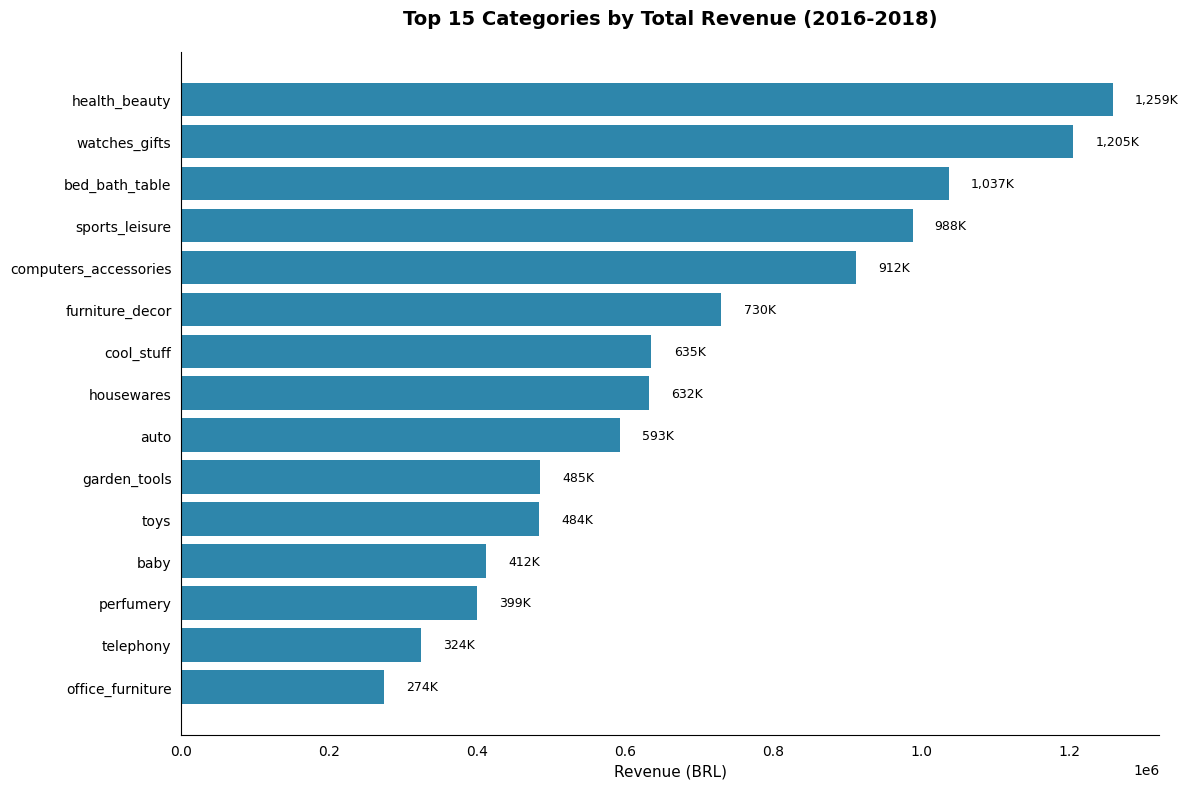

Chart saved to outputs/top_15_categories_revenue.png ✅


In [11]:
# Bar chart: top 15 categories by revenue
top_15 = revenue_by_category.head(15).reset_index()

fig, ax = plt.subplots(figsize=(12, 8))

# Use a clean color
ax.barh(
    top_15['product_category_name_english'][::-1],  # reverse so biggest is at top
    top_15['total_revenue_brl'][::-1],
    color='#2E86AB'
)

# Format
ax.set_xlabel('Revenue (BRL)', fontsize=11)
ax.set_title('Top 15 Categories by Total Revenue (2016-2018)', fontsize=14, weight='bold', pad=20)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(left=False, bottom=False)

# Add value labels on bars
for i, v in enumerate(top_15['total_revenue_brl'][::-1]):
    ax.text(v + 30000, i, f'{v/1000:,.0f}K', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/top_15_categories_revenue.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved to outputs/top_15_categories_revenue.png ✅")

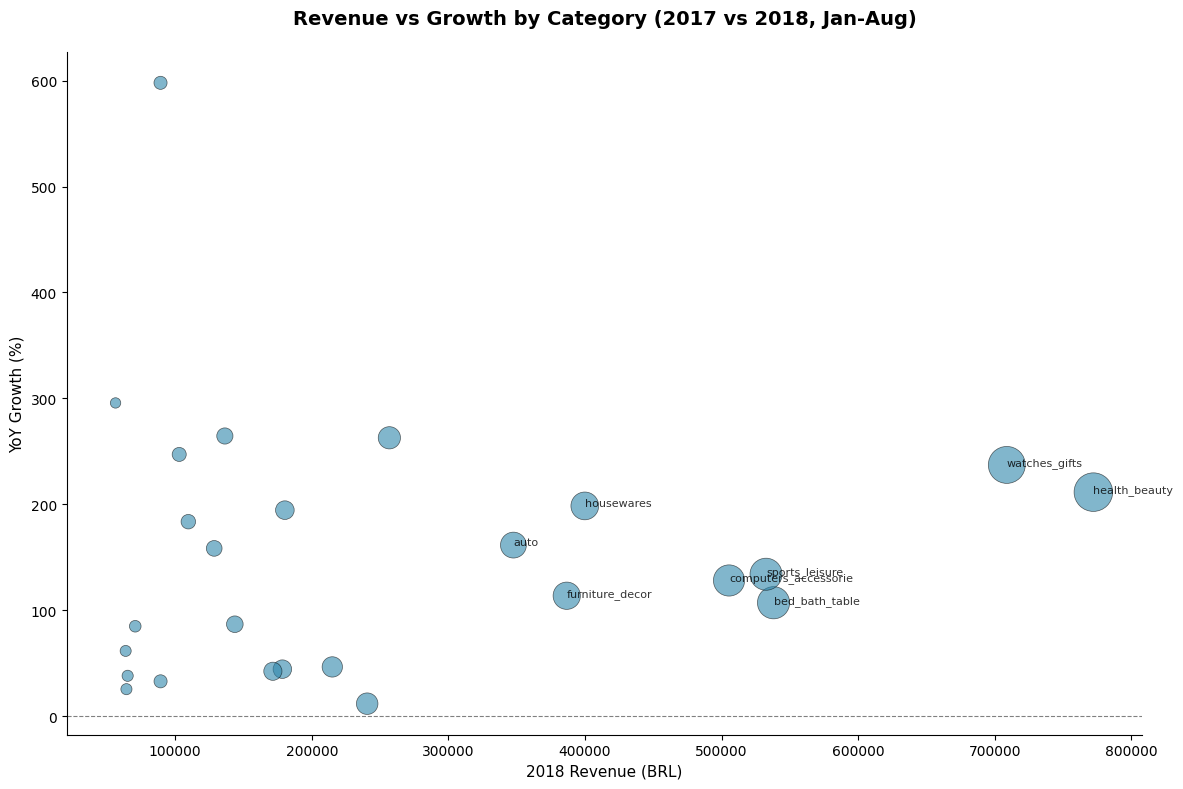

Chart saved ✅


In [12]:
# Scatter: revenue (size = importance) vs growth rate
strategic_chart = meaningful.copy()
strategic_chart = strategic_chart[strategic_chart[2018] >= 50000]

fig, ax = plt.subplots(figsize=(12, 8))

# Color by growth direction
colors = ['#2E86AB' if g > 0 else '#D62828' for g in strategic_chart['growth_pct']]

ax.scatter(
    strategic_chart[2018],
    strategic_chart['growth_pct'],
    s=strategic_chart[2018] / 1000,  # bubble size = revenue
    c=colors,
    alpha=0.6,
    edgecolors='black',
    linewidth=0.5
)

# Reference line at 0% growth
ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')

# Labels for top categories
top_strategic = strategic_chart.nlargest(8, 2018)
for cat, row in top_strategic.iterrows():
    ax.annotate(
        cat[:20], 
        (row[2018], row['growth_pct']),
        fontsize=8,
        alpha=0.8
    )

ax.set_xlabel('2018 Revenue (BRL)', fontsize=11)
ax.set_ylabel('YoY Growth (%)', fontsize=11)
ax.set_title('Revenue vs Growth by Category (2017 vs 2018, Jan-Aug)', fontsize=14, weight='bold', pad=20)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../outputs/revenue_vs_growth_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved ✅")